In [11]:
# Authors: The scikit-learn developers
# SPDX-License-Identifier: BSD-3-Clause

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn import datasets, ensemble
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.utils.fixes import parse_version

In [22]:
def dataframe_to_sklearn_dataset(df):
    """
    Convert a pandas DataFrame into an sklearn-style regression dataset.

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame with x columns:
        - first x-1 columns are features
        - last column is the target

    Returns
    -------
    dict
        sklearn-style dataset dictionary
    """

    feature_names = df.columns[:-1].tolist()
    target_name = df.columns[-1]

    data = df.iloc[:, :-1].to_numpy(dtype=float)
    target = df.iloc[:, -1].to_numpy(dtype=float)

    dataset = {
        "data": data,
        "target": target,
        "frame": None,
        "target_names": [target_name],
        "feature_names": feature_names,
    }

    return dataset

def mse_to_scaled_rmse(mse, y_max): 
    mse_scaled = mse * (y_max ** 2) 
    rmse_scaled = np.sqrt(mse_scaled)
    return rmse_scaled

In [13]:
data = pd.read_csv(r'C:\Users\amyry\OneDrive - University of Cambridge\NanoDTC_\Coding\pml_supercond\data\raw\train.csv')
data.head()
data.columns

Index(['number_of_elements', 'mean_atomic_mass', 'wtd_mean_atomic_mass',
       'gmean_atomic_mass', 'wtd_gmean_atomic_mass', 'entropy_atomic_mass',
       'wtd_entropy_atomic_mass', 'range_atomic_mass', 'wtd_range_atomic_mass',
       'std_atomic_mass', 'wtd_std_atomic_mass', 'mean_fie', 'wtd_mean_fie',
       'gmean_fie', 'wtd_gmean_fie', 'entropy_fie', 'wtd_entropy_fie',
       'range_fie', 'wtd_range_fie', 'std_fie', 'wtd_std_fie',
       'mean_atomic_radius', 'wtd_mean_atomic_radius', 'gmean_atomic_radius',
       'wtd_gmean_atomic_radius', 'entropy_atomic_radius',
       'wtd_entropy_atomic_radius', 'range_atomic_radius',
       'wtd_range_atomic_radius', 'std_atomic_radius', 'wtd_std_atomic_radius',
       'mean_Density', 'wtd_mean_Density', 'gmean_Density',
       'wtd_gmean_Density', 'entropy_Density', 'wtd_entropy_Density',
       'range_Density', 'wtd_range_Density', 'std_Density', 'wtd_std_Density',
       'mean_ElectronAffinity', 'wtd_mean_ElectronAffinity',
       'gmean_

In [14]:
data_sk = dataframe_to_sklearn_dataset(data)
print(data_sk)

{'data': array([[ 4.        , 88.9444675 , 57.86269229, ...,  1.08571429,
         0.4330127 ,  0.43705882],
       [ 5.        , 92.729214  , 58.51841614, ...,  1.12857143,
         0.63245553,  0.46860627],
       [ 4.        , 88.9444675 , 57.88524186, ...,  1.11428571,
         0.4330127 ,  0.44469664],
       ...,
       [ 2.        , 99.66319   , 95.609104  , ...,  3.2       ,
         0.5       ,  0.4       ],
       [ 2.        , 99.66319   , 97.0956022 , ...,  2.21      ,
         0.5       ,  0.46249324],
       [ 3.        , 87.46833333, 86.8585    , ...,  1.8       ,
         1.41421356,  1.5       ]], shape=(21263, 81)), 'target': array([29.  , 26.  , 19.  , ...,  1.98,  1.84, 12.8 ], shape=(21263,)), 'frame': None, 'target_names': ['critical_temp'], 'feature_names': ['number_of_elements', 'mean_atomic_mass', 'wtd_mean_atomic_mass', 'gmean_atomic_mass', 'wtd_gmean_atomic_mass', 'entropy_atomic_mass', 'wtd_entropy_atomic_mass', 'range_atomic_mass', 'wtd_range_atomic_mass', 

In [15]:
# Read data
X, y = data_sk['data'], data_sk['target']

print(X.shape)
#X = X.reshape(1,21263,81)
print(X.shape)

# Apply normalisation
X_norm = X / X.max(axis=0)
y_max = y.max()
y_norm = y / y_max
print(y_max)


# train-test split for model evaluation
X_train, X_test, y_train, y_test = train_test_split(X_norm, y_norm, train_size=0.7, shuffle=True)
print(f"Filtered Train Shape: {X_train.shape}") 
print(f"Filtered Test Shape: {X_test.shape}")

# Convert to 2D PyTorch tensors
#X_train = torch.tensor(X_train, dtype=torch.float32)
#y_train = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1)
#X_test = torch.tensor(X_test, dtype=torch.float32).unsqueeze(1)
#y_test = torch.tensor(y_test, dtype=torch.float32).reshape(-1, 1)


(21263, 81)
(21263, 81)
185.0
Filtered Train Shape: (14884, 81)
Filtered Test Shape: (6379, 81)


In [16]:
#X_train, X_test, y_train, y_test = train_test_split(
#    X, y, test_size=0.1, random_state=13
#)

params = {
    "n_estimators": 374,
    "max_depth": 16,
    "min_samples_split": 5,
    "learning_rate": 0.02,
    "loss": "squared_error",
    "subsample": 0.5,
}

In [17]:
reg = ensemble.GradientBoostingRegressor(**params)
reg.fit(X_train, y_train)

mse = mean_squared_error(y_test, reg.predict(X_test))
print("The mean squared error (MSE) on test set: {:.4f}".format(mse))

The mean squared error (MSE) on test set: 0.0027


In [21]:
print(mse_to_scaled_rmse(mse, y_max))

9.563013949380426


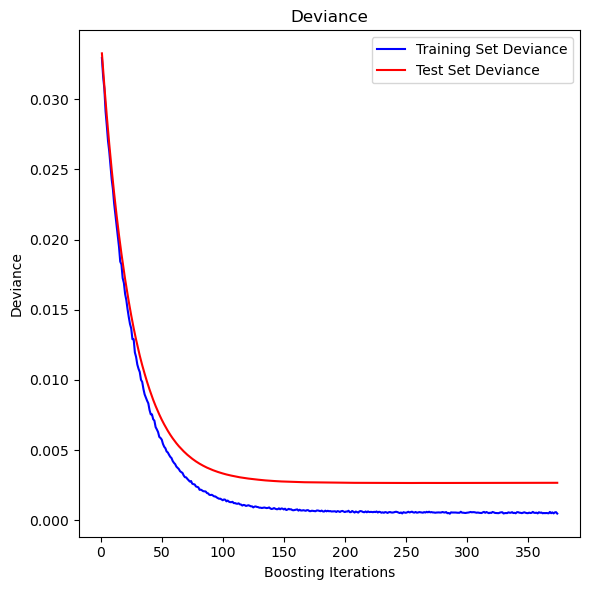

In [19]:
test_score = np.zeros((params["n_estimators"],), dtype=np.float64)
for i, y_pred in enumerate(reg.staged_predict(X_test)):
    test_score[i] = mean_squared_error(y_test, y_pred)

fig = plt.figure(figsize=(6, 6))
plt.subplot(1, 1, 1)
plt.title("Deviance")
plt.plot(
    np.arange(params["n_estimators"]) + 1,
    reg.train_score_,
    "b-",
    label="Training Set Deviance",
)
plt.plot(
    np.arange(params["n_estimators"]) + 1, test_score, "r-", label="Test Set Deviance"
)
plt.legend(loc="upper right")
plt.xlabel("Boosting Iterations")
plt.ylabel("Deviance")
fig.tight_layout()
plt.show()